In [7]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:98% !important;}
div.cell.code_cell.rendered{width:100%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:20pt;}
div.text_cell_render.rendered_html{font-size:18pt;}
div.text_cell_render.rendered_html{font-size:15pt;}
div.output {font-size:18pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:18pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:18pt;padding:5px;}
table.dataframe{font-size:18px;}
</style>
"""))

# 1. tensorflow v2.xx에서 v1사용하기

In [27]:
import tensorflow.compat.v1 as tf
tf.disable_v2_behavior()  # v2를 비활성화하고 v1활성화
import numpy as np
import pandas as pd

## Tensorflow
- 데이터 흐름 그래프(tensor객체의 흐름)
- 이 그래프는 node(상수, 변수, 연산)와 edge로 구성
- sess = tf.Session()으로 실행
- sess.run()을 통해 값을 확인

In [28]:
# tensor = data(상수, 변수)와 연산
node1 = tf.constant('Hello, Tensorflow')
sess = tf.Session()
print(sess.run(node1))

b'Hello, Tensorflow'


In [29]:
# 간단한 연산 tensor 그래프
node1 = tf.constant(10, dtype=tf.float16)
node2 = tf.constant(20, dtype=tf.float16)
node3 = tf.add(node1, node2)
sess = tf.Session()
print(sess.run([node1, node2, node3]))

[10.0, 20.0, 30.0]


In [30]:
# 타입 변경
node1 = tf.constant(np.array([1,2,3]), dtype=tf.int16)
node2 = tf.cast(node1, dtype=tf.float32)
sess = tf.Session()
sess.run([node1, node2])

[array([1, 2, 3], dtype=int16), array([1., 2., 3.], dtype=float32)]

In [31]:
# 평균값 계산 : tf.reduce_mean()
data = np.array([1., 2., 3.])
tensor = tf.reduce_mean(data)
sess = tf.Session()
sess.run(tensor)

2.0

In [32]:
# 랜덤값을 갖는 tensor
a = tf.random_normal([2]) # 평균0, 표준편차가 1인 난수 실수 2개(정규분포이루는난수)
b = tf.random_normal([1])
sess = tf.Session()
sess.run([a,b])

[array([-0.14331107,  0.8363769 ], dtype=float32),
 array([-1.0856328], dtype=float32)]

In [33]:
w = tf.Variable(tf.random.normal([1]))
sess = tf.Session()
sess.run(tf.global_variables_initializer()) # w변수의 난수 초기화
sess.run(w)

array([-0.54561293], dtype=float32)

# 2. tensorflow v1을 이용한 linear regression을 구현
## 2.1 입력(독립)변수 x가 1개, 타겟(종속)변수 y가 1개

In [34]:
x = np.array([1,2,3])
y = np.array([2,3,4])
# weight오 bias(처음엔 랜덤값으로 셋팅, 학습과정에서 변경)
W = tf.Variable(tf.random.normal([1]), name='weight')
b = tf.Variable(tf.random.normal([1]), name='bias')
# Hypothesis : 예측값
H = W*x + b
#cost function(손실함수 = mse;최소제곱법)
cost = tf.reduce_mean(tf.square(H-y))
'''
학습목적 : cost가 최소가 되는 W, b를 찾아내는 것
cost는 2차함수이므로 곡선그래프. 곡선위 미분값이 줄어드는 방향으로 학습(경사하강)
=> GradientDescentOptimizer
'''
optimizer = tf.train.GradientDescentOptimizer(learning_rate=0.01)
train = optimizer.minimize(cost)
# Session 생성
sess = tf.Session()
# W, b 변수 노드에 초기화
sess.run(tf.global_variables_initializer())
# 5000번 학습 (v2에서는 fit함수)
for step in range(5001):
    _, cost_val, W_val, b_val = sess.run([train, cost, W, b])
    if step%200 == 0:
        print("{}번째 cost:{}, W:{}, b:{}".format(step,
                                               cost_val,
                                               W_val,
                                               b_val))

0번째 cost:7.948467254638672, W:[0.00461636], b:[0.61961114]
200번째 cost:0.00012768289889208972, W:[0.9869077], b:[1.0297618]
400번째 cost:4.875785452895798e-05, W:[0.9919095], b:[1.0183916]
600번째 cost:1.8618482499732636e-05, W:[0.99500066], b:[1.0113648]
800번째 cost:7.108998033800162e-06, W:[0.9969107], b:[1.0070227]
1000번째 cost:2.7141795726493e-06, W:[0.9980911], b:[1.0043393]
1200번째 cost:1.0366585456722532e-06, W:[0.9988203], b:[1.0026817]
1400번째 cost:3.9598640455551504e-07, W:[0.9992709], b:[1.0016572]
1600번째 cost:1.5134952491280274e-07, W:[0.9995491], b:[1.0010247]
1800번째 cost:5.7988724933011326e-08, W:[0.99972093], b:[1.0006341]
2000번째 cost:2.222987838251811e-08, W:[0.99982715], b:[1.0003928]
2200번째 cost:8.653681327075446e-09, W:[0.99989223], b:[1.0002449]
2400번째 cost:3.396039005565399e-09, W:[0.99993265], b:[1.0001534]
2600번째 cost:1.3360571538001409e-09, W:[0.9999577], b:[1.0000964]
2800번째 cost:5.496000876625828e-10, W:[0.9999731], b:[1.0000619]
3000번째 cost:2.0842587378222532e-10, W:[

In [35]:
# 최종적으로 나온 회귀식 : H = W*x + b
sess.run([W, b])

[array([0.9999891], dtype=float32), array([1.0000248], dtype=float32)]

In [36]:
W_, b_ = sess.run([W, b])
W_[0], b_[0]

(0.9999891, 1.0000248)

In [37]:
def predict(x):
    return W_[0]*x + b_[0]

In [38]:
input_x = int(input('입력값은 ?'))
print('예측값은 ', predict(input_x))

입력값은 ?1
예측값은  2.0000138878822327


## 2.2 predict를 위한 placeholder이용
- placeholder : 텐서플로우 외부에서 데이터를 입력받는 노드

In [39]:
# x = np.array([1,2,3])
x = tf.placeholder(tf.float16)
H = 1*x + 1
sess = tf.Session()
sess.run(H, feed_dict={x:5})
sess.run(H, feed_dict={x:np.array([1,2,3])})

array([2., 3., 4.], dtype=float16)

In [40]:
# H = 2x+1
x_data = np.array([1,2,3,5,8])
y_data = np.array([3,5,7,11,17])
# placeholder 설정 (입력변수 x, 타겟변수 y)
x = tf.placeholder(dtype=tf.float32)
y = tf.placeholder(dtype=tf.float32)
# W, b
W = tf.Variable(tf.random.normal([1]))
b = tf.Variable(tf.random.normal([1]))
# Hypothesis(예측값)
H = W*x + b
# 손실함수
cost = tf.reduce_mean(tf.square(H-y))
# 경사하강법
train = tf.train.GradientDescentOptimizer(learning_rate=0.01).minimize(cost)
# Session 객체 생성
sess = tf.Session()
sess.run(tf.global_variables_initializer()) # W, b 초기화
# 5000번 학습
for step in range(5001):
    _, cost_val, W_val, b_val = sess.run([train, cost, W, b], 
                                         feed_dict={x:x_data,
                                                   y:y_data})
    if step%200 == 0:
        print('{}째 : cost:{}, W:{}, b:{}'.format(step, cost_val, W_val, b_val))

0째 : cost:499.8168029785156, W:[-0.554883], b:[-0.45026162]
200째 : cost:0.02626972459256649, W:[2.0551193], b:[0.7053886]
400째 : cost:0.00258385157212615, W:[2.0172865], b:[0.90760344]
600째 : cost:0.0002541362482588738, W:[2.0054214], b:[0.9710227]
800째 : cost:2.4998607841553167e-05, W:[2.0017002], b:[0.990912]
1000째 : cost:2.4587220650573727e-06, W:[2.0005333], b:[0.9971497]
1200째 : cost:2.4180727109524014e-07, W:[2.0001674], b:[0.99910575]
1400째 : cost:2.38403110586205e-08, W:[2.0000525], b:[0.9997193]
1600째 : cost:2.370779794702571e-09, W:[2.0000165], b:[0.9999119]
1800째 : cost:2.467118176419092e-10, W:[2.0000055], b:[0.9999716]
2000째 : cost:3.310560853231337e-11, W:[2.0000021], b:[0.99998933]
2200째 : cost:2.060005464821213e-11, W:[2.0000017], b:[0.99999213]
2400째 : cost:2.060005464821213e-11, W:[2.0000017], b:[0.99999213]
2600째 : cost:2.060005464821213e-11, W:[2.0000017], b:[0.99999213]
2800째 : cost:2.060005464821213e-11, W:[2.0000017], b:[0.99999213]
3000째 : cost:2.060005464821213

In [41]:
# 예측하기
sess.run(H, feed_dict={x:5})

array([11.000001], dtype=float32)

In [42]:
sess.run(H, feed_dict={x:np.array([5, 6, 7])})

array([11.000001, 13.000002, 15.000004], dtype=float32)

## 2.3 scale이 다른 데이터의 linear regression 구현(scale조정 x)

In [14]:
x_data = np.array([1,2,5,8,10])
y_data = np.array([3,15,68,80,95])
# placeholder 설정 (입력변수 x, 타겟변수 y)
x = tf.placeholder(dtype=tf.float32)
y = tf.placeholder(dtype=tf.float32)
# W, b
W = tf.Variable(tf.random.normal([1]))
b = tf.Variable(tf.random.normal([1]))
# Hypothesis(예측값)
H = W*x + b
# 손실함수
cost = tf.reduce_mean(tf.square(H-y))
# 경사하강법
train = tf.train.GradientDescentOptimizer(learning_rate=0.01).minimize(cost)
# Session 객체 생성
sess = tf.Session()
sess.run(tf.global_variables_initializer()) # W, b 초기화
# 5000번 학습
for step in range(2001):
    _, cost_val, W_val, b_val = sess.run([train, cost, W, b], 
                                         feed_dict={x:x_data,
                                                   y:y_data})
    if step%200 == 0:
        print('{}째 : cost:{}, W:{}, b:{}'.format(step, cost_val, W_val, b_val))

0째 : cost:4569.0673828125, W:[7.60434], b:[1.8967773]
200째 : cost:83.8410873413086, W:[10.156671], b:[-0.29274958]
400째 : cost:83.51522064208984, W:[10.258484], b:[-1.0466014]
600째 : cost:83.48533630371094, W:[10.289322], b:[-1.2749382]
800째 : cost:83.48258209228516, W:[10.298662], b:[-1.3440993]
1000째 : cost:83.48235321044922, W:[10.301492], b:[-1.3650476]
1200째 : cost:83.48231506347656, W:[10.302349], b:[-1.3713927]
1400째 : cost:83.48231506347656, W:[10.3026085], b:[-1.3733151]
1600째 : cost:83.48230743408203, W:[10.302687], b:[-1.3738965]
1800째 : cost:83.48233032226562, W:[10.30271], b:[-1.374072]
2000째 : cost:83.48230743408203, W:[10.302717], b:[-1.3741232]


In [ ]:
# cost값이 멈춤 : local 최소값

#### -- 위에꺼 텐서2 버전

In [15]:
# 위에꺼텐서2 버전
import numpy as np
import tensorflow as tf
# 텐서2버전실행코드
import tensorflow as tf
tf.compat.v1.enable_eager_execution()

# 데이터
x_data = np.array([1,2,5,8,10], dtype=np.float32)
y_data = np.array([3,15,68,80,95], dtype=np.float32)

# 변수 정의
W = tf.Variable(tf.random.normal([1]))
b = tf.Variable(tf.random.normal([1]))

# 학습률
learning_rate = 0.01

# 경사하강법 학습 루프
for step in range(5001):
    with tf.GradientTape() as tape:
        H = W * x_data + b
        cost = tf.reduce_mean(tf.square(H - y_data))

    gradients = tape.gradient(cost, [W, b])
    W.assign_sub(learning_rate * gradients[0])
    b.assign_sub(learning_rate * gradients[1])

    if step % 200 == 0:
        print(f"{step}번째: cost={cost.numpy()}, W={W.numpy()}, b={b.numpy()}")

AttributeError: 'Tensor' object has no attribute 'numpy'

## 2.4 scale이 다른 데이터의 linear regression을 구현(scale 조정O)
### scale을 맞추기 : 모든 데이터를 일정 범위내로 조정
- normalization(정규화) : 0~1로 조정
                      X - Xmin
    nomalization = ───────
                    Xmax - Xmin
        * 위의 식을 써도 되지만 라이브러리를 씀(sklearn.preprocessing.MinMaxScaler이용)
        
- standardization(표준화) : 평균 0, 표준편차 1로 조정
                        X - Xmean(평균)
    standardization = ─────────
                        Xstd(표준편차)
        * 위의 식을 써도 되지만 라이브러리를 씀(sklearn.preprocessing.StandardScaler이용)

#### 라이브러리를 쓰지 않고 정규화(nomalization방법)
- normalization(정규화) : 0~1로 조정

                X - Xmin
nomalization = ───────

              Xmax - Xmin
  * 위의 식을 써도 되지만 라이브러리를 씀(sklearn.preprocessing.MinMaxScaler이용)

In [22]:
# 라이브러리를 쓰지 않고 정규화
x_data = np.array([1,2,5,8,10])
y_data = np.array([3,15,68,80,95])
# nomalization 방법
scaled_x_data = (x_data - x_data.min()) / (x_data.max() - x_data.min())
scaled_y_data = (y_data - y_data.min()) / (y_data.max() - y_data.min())
print(scaled_x_data)
print(scaled_y_data)

[0.         0.11111111 0.44444444 0.77777778 1.        ]
[0.         0.13043478 0.70652174 0.83695652 1.        ]


#### 라이브러리를 쓰고 정규화 (MinMaxScaler이용)

In [43]:
# 라이브러리를 쓰고 정규화 (MinMaxScaler이용)
x_data = np.array([1,2,5,8,10]).reshape(-1, 1) # 5열데이터 -> 5행 1열 데이터로 변경(축 하나 추가)
y_data = np.array([3,15,68,80,95]).reshape(-1, 1)
#np.column_stack([x_data, y_data])

from sklearn.preprocessing import MinMaxScaler
scaler_x = MinMaxScaler() # x_data를 정규화시킬 객체
# scaler_x.fit(x_data)
# scaled_x_data = scaler_x.transform(x_data)
scaled_x_data = scaler_x.fit_transform(x_data)
scaled_x_data
#y_data를 정규화시킬 객체
scaler_y = MinMaxScaler()
scaled_y_data = scaler_y.fit_transform(y_data)
np.column_stack([x_data, y_data, scaled_x_data, scaled_y_data])

array([[ 1.        ,  3.        ,  0.        ,  0.        ],
       [ 2.        , 15.        ,  0.11111111,  0.13043478],
       [ 5.        , 68.        ,  0.44444444,  0.70652174],
       [ 8.        , 80.        ,  0.77777778,  0.83695652],
       [10.        , 95.        ,  1.        ,  1.        ]])

In [47]:
# placeholder 설정 (입력변수 x, 타겟변수 y)
x = tf.placeholder(dtype=tf.float32)
y = tf.placeholder(dtype=tf.float32)
# W, b 초기화
W = tf.Variable(tf.random.normal([1]))
b = tf.Variable(tf.random.normal([1]))
# Hypothesis(예측값)
H = W*x + b
# 손실함수
cost = tf.reduce_mean(tf.square(H-y))
# 경사하강법
train = tf.train.GradientDescentOptimizer(learning_rate=0.01).minimize(cost)
# Session 객체 생성
sess = tf.Session()
sess.run(tf.global_variables_initializer()) # W, b 초기화
# 12000번 학습
for step in range(12001):
    _, cost_val, W_val, b_val = sess.run([train, cost, W, b], 
                                         feed_dict={x:scaled_x_data,
                                                   y:scaled_y_data})
    if step%600 == 0:
        print('{}째 : cost:{}, W:{}, b:{}'.format(step, cost_val, W_val, b_val))

0째 : cost:1.0294406414031982, W:[0.26009393], b:[-0.52944136]
600째 : cost:0.010913077741861343, W:[0.9241214], b:[0.10867832]
1200째 : cost:0.009927150793373585, W:[0.9872078], b:[0.07535706]
1800째 : cost:0.009867118671536446, W:[1.002775], b:[0.06713471]
2400째 : cost:0.009863459505140781, W:[1.0066162], b:[0.06510583]
3000째 : cost:0.009863238781690598, W:[1.0075631], b:[0.0646054]
3600째 : cost:0.009863222949206829, W:[1.0077971], b:[0.06448232]
4200째 : cost:0.009863222017884254, W:[1.0078526], b:[0.06445197]
4800째 : cost:0.009863224811851978, W:[1.0078539], b:[0.06445099]
5400째 : cost:0.009863224811851978, W:[1.0078539], b:[0.06445099]
6000째 : cost:0.009863224811851978, W:[1.0078539], b:[0.06445099]
6600째 : cost:0.009863224811851978, W:[1.0078539], b:[0.06445099]
7200째 : cost:0.009863224811851978, W:[1.0078539], b:[0.06445099]
7800째 : cost:0.009863224811851978, W:[1.0078539], b:[0.06445099]
8400째 : cost:0.009863224811851978, W:[1.0078539], b:[0.06445099]
9000째 : cost:0.0098632248118519

#### 예측 predict

In [50]:
# 예측 : 모델에 scale 조정된 값으로 예측 => scale 조정된 y값
scaled_input = scaler_x.transform(np.array([[2],[3]]))

print('모델 예측을 위한 입력 :',scaled_input, sep='\n')
scaled_output = sess.run(H, feed_dict={x:scaled_input})
print('모델 예측 결과 :',scaled_output,sep='\n')
print('결과 :', scaler_y.inverse_transform(scaled_output), sep='\n')

모델 예측을 위한 입력 :
[[0.11111111]
 [0.22222222]]
모델 예측 결과 :
[[0.17643476]
 [0.28841853]]
결과 :
[[19.231998]
 [29.534504]]


#### x_data들의 예측값

In [54]:
# x_data들의 예측값
scaled_y_hat = sess.run(H, feed_dict = { x: scaled_x_data })
y_hat = scaler_y.inverse_transform(scaled_y_hat)

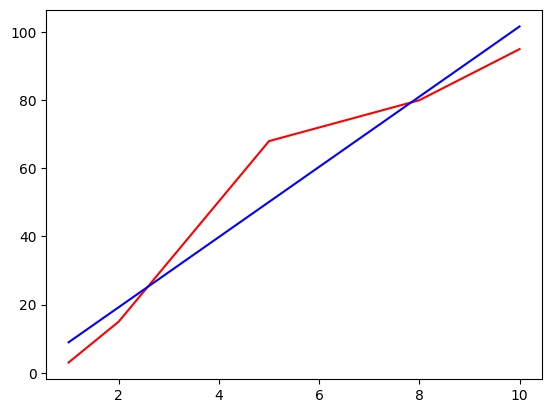

In [55]:
import matplotlib.pyplot as plt
plt.plot(x_data, y_data, 'r')
plt.plot(x_data, y_hat, 'b')

#### 라이브러리를 사용하여 표준화(StandardScaler)

In [57]:
# 라이브러리를 사용하여 표준화(StandardScaler)
x_data = np.array([1,2,5,8,10]).reshape(-1, 1) # 5열데이터 -> 5행 1열 데이터로 변경(축 하나 추가)
y_data = np.array([3,15,68,80,95]).reshape(-1, 1)

from sklearn.preprocessing import StandardScaler
scaler_x = StandardScaler() # x_data를 표준화할 객체
scaler_y = StandardScaler() # y_data를 표준화할 객체
scaled_x_data = scaler_x.fit_transform(x_data)
scaled_y_data = scaler_y.fit_transform(y_data)
print(np.column_stack([x_data, y_data]))
print(np.column_stack([scaled_x_data, scaled_y_data]))

[[ 1  3]
 [ 2 15]
 [ 5 68]
 [ 8 80]
 [10 95]]
[[-1.22474487 -1.34819316]
 [-0.93313895 -1.01936556]
 [-0.05832118  0.43295634]
 [ 0.81649658  0.76178394]
 [ 1.39970842  1.17281844]]


In [58]:
# placeholder 설정 (입력변수 x, 타겟변수 y)
x = tf.placeholder(dtype=tf.float32)
y = tf.placeholder(dtype=tf.float32)
# W, b 초기화
W = tf.Variable(tf.random.normal([1]))
b = tf.Variable(tf.random.normal([1]))
# Hypothesis(예측값)
H = W*x + b
# 손실함수
cost = tf.reduce_mean(tf.square(H-y))
# 경사하강법
train = tf.train.GradientDescentOptimizer(learning_rate=0.001).minimize(cost)
# Session 객체 생성
sess = tf.Session()
sess.run(tf.global_variables_initializer()) # W, b 초기화
# 12000번 학습
for step in range(12001):
    _, cost_val, W_val, b_val = sess.run([train, cost, W, b], 
                                         feed_dict={x:scaled_x_data,
                                                   y:scaled_y_data})
    if step%600 == 0:
        print('{}째 : cost:{}, W:{}, b:{}'.format(step, cost_val, W_val, b_val))

0째 : cost:1.806256890296936, W:[-0.17785059], b:[-0.6506049]
600째 : cost:0.22047916054725647, W:[0.62339574], b:[-0.19572292]
1200째 : cost:0.07696599513292313, W:[0.86443686], b:[-0.05887986]
1800째 : cost:0.06397807598114014, W:[0.93694955], b:[-0.01771296]
2400째 : cost:0.06280266493558884, W:[0.9587636], b:[-0.00532863]
3000째 : cost:0.06269629299640656, W:[0.9653261], b:[-0.00160302]
3600째 : cost:0.06268666684627533, W:[0.9673005], b:[-0.00048223]
4200째 : cost:0.06268579512834549, W:[0.96789443], b:[-0.00014506]
4800째 : cost:0.06268570572137833, W:[0.9680732], b:[-4.363154e-05]
5400째 : cost:0.06268569827079773, W:[0.9681254], b:[-1.3116493e-05]
6000째 : cost:0.06268569827079773, W:[0.96813506], b:[-3.9286992e-06]
6600째 : cost:0.06268568336963654, W:[0.96813506], b:[-1.1631142e-06]
7200째 : cost:0.06268569082021713, W:[0.96813506], b:[-3.3116964e-07]
7800째 : cost:0.06268568336963654, W:[0.96813506], b:[-8.08822e-08]
8400째 : cost:0.06268569827079773, W:[0.96813506], b:[-1.3335292e-08]
900

In [59]:
# x_data들의 예측값
scaled_y_hat = sess.run(H, feed_dict = { x: scaled_x_data })
y_hat = scaler_y.inverse_transform(scaled_y_hat)

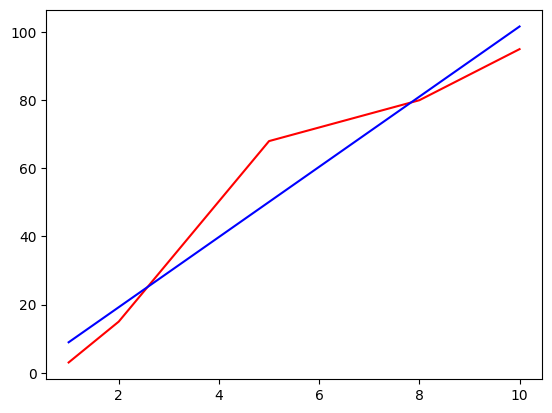

In [60]:
import matplotlib.pyplot as plt
plt.plot(x_data, y_data, 'r')
plt.plot(x_data, y_hat, 'b')